# IMPORT LIBRARY


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

# MEMUAT DATASET + CLEANING
ASSESING


In [65]:
path_to_zip = 'Dataset OULAD.zip'
files_to_extract = [
    'assessments.csv',
    'studentAssessment.csv',
    'studentInfo.csv',
    'studentRegistration.csv'
]

In [66]:
with zipfile.ZipFile(path_to_zip, 'r') as zip_ref:
    for file in files_to_extract:
        zip_ref.extract(file)
        print(f"File {file} berhasil di-extract!")

File assessments.csv berhasil di-extract!
File studentAssessment.csv berhasil di-extract!
File studentInfo.csv berhasil di-extract!
File studentRegistration.csv berhasil di-extract!


In [67]:
student_info = pd.read_csv('studentInfo.csv')
student_registration = pd.read_csv('studentRegistration.csv')
student_assessment = pd.read_csv('studentAssessment.csv')
assessments = pd.read_csv('assessments.csv')

# Merging StudentInfo dan Student registration

In [68]:
student_data = pd.merge(student_registration, student_info, on=['id_student', 'code_module', 'code_presentation'], how='left')

In [69]:
print("### Student Info Head ###")
print(student_info.head())

### Student Info Head ###
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  
0              240          N         Pass  
1               60

# Mergin Student Assessment

In [70]:
student_assessment_data = pd.merge(student_assessment, assessments,
                               on='id_assessment',
                               how='left')

Cek Nilai yang Kosong


In [71]:
missing_values = student_assessment_data.isnull().sum()
missing_values

,0
id_assessment,0
id_student,0
date_submitted,0
is_banked,0
score,173
code_module,0
code_presentation,0
assessment_type,0
date,2865
weight,0


In [72]:
student_assessment_data['score'] = student_assessment_data['score'].fillna(0)

student_assessment_data = student_assessment_data.dropna(subset=['date'])

In [73]:
student_data_final = pd.merge(student_assessment_data, student_data,
                         on=['id_student', 'code_module', 'code_presentation'],
                         how='inner')

In [74]:
student_data_final.head()

,id_assessment,id_student,date_submitted,is_banked,score,code_module,code_presentation,assessment_type,date,weight,...,date_unregistration,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,1752,11391,18,0,78.0,AAA,2013J,TMA,19.0,10.0,...,NaN,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,1752,28400,22,0,70.0,AAA,2013J,TMA,19.0,10.0,...,NaN,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,1752,31604,17,0,72.0,AAA,2013J,TMA,19.0,10.0,...,NaN,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
3,1752,32885,26,0,69.0,AAA,2013J,TMA,19.0,10.0,...,NaN,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass
4,1752,38053,19,0,79.0,AAA,2013J,TMA,19.0,10.0,...,NaN,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,Pass


In [75]:
student_data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171047 entries, 0 to 171046
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id_assessment         171047 non-null  int64  
 1   id_student            171047 non-null  int64  
 2   date_submitted        171047 non-null  int64  
 3   is_banked             171047 non-null  int64  
 4   score                 171047 non-null  float64
 5   code_module           171047 non-null  object 
 6   code_presentation     171047 non-null  object 
 7   assessment_type       171047 non-null  object 
 8   date                  171047 non-null  float64
 9   weight                171047 non-null  float64
 10  date_registration     171040 non-null  float64
 11  date_unregistration   13055 non-null   float64
 12  gender                171047 non-null  object 
 13  region                171047 non-null  object 
 14  highest_education     171047 non-null  object 
 15  

In [76]:
student_data_final.describe()

,id_assessment,id_student,date_submitted,is_banked,score,date,weight,date_registration,date_unregistration,num_of_prev_attempts,studied_credits
count,171047.000000,1.710470e+05,171047.000000,171047.000000,171047.000000,171047.000000,171047.000000,171040.000000,13055.000000,171047.000000,171047.000000
mean,26585.673072,7.048521e+05,113.947634,0.011161,75.869398,130.605623,11.282379,-65.846352,138.127461,0.145966,76.823739
std,8899.723129,5.527830e+05,70.221546,0.105053,18.854015,78.025175,13.974538,46.965517,61.123371,0.447014,37.364222
min,1752.000000,6.516000e+03,-11.000000,0.000000,0.000000,12.000000,0.000000,-311.000000,-196.000000,0.000000,30.000000
25%,15022.000000,5.041050e+05,51.000000,0.000000,66.000000,54.000000,0.000000,-94.000000,95.000000,0.000000,60.000000
50%,25360.000000,5.848270e+05,115.000000,0.000000,80.000000,129.000000,9.000000,-53.000000,145.000000,0.000000,60.000000
75%,34883.000000,6.342650e+05,171.000000,0.000000,90.000000,214.000000,18.000000,-29.000000,184.000000,0.000000,90.000000
max,37443.000000,2.698588e+06,608.000000,1.000000,100.000000,261.000000,100.000000,167.000000,444.000000,6.000000,630.000000


In [77]:
# Menghitung median dari date_registration
median_reg = student_data_final['date_registration'].median()

# Mengisi 7 data yang kosong tadi dengan median
student_data_final['date_registration'] = student_data_final['date_registration'].fillna(median_reg)

print(f"Selesai! date_registration sekarang sudah penuh. Median: {median_reg}")

Selesai! date_registration sekarang sudah penuh. Median: -53.0


In [78]:
# 1. data diurutkan berdasarkan ID dan waktu kirim paling awal
df_sorted = student_data_final.sort_values(by=['id_student', 'date_submitted'])

# 2. Ambil TMA PERTAMA
tma_first = df_sorted[df_sorted['assessment_type'] == 'TMA'].groupby('id_student').first()[['score']].rename(columns={'score': 'score_TMA'})

# 3. Ambil CMA PERTAMA
cma_first = df_sorted[df_sorted['assessment_type'] == 'CMA'].groupby('id_student').first()[['score']].rename(columns={'score': 'score_CMA'})

# 4. Gabungkan TMA & CMA (Outer Join: Supaya yang cuma punya salah satu tetep aman)
df_scores = pd.merge(tma_first, cma_first, on='id_student', how='outer').fillna(0)

# 5. [LOGIKA GABUNGAN] Buat Skor Tunggal untuk Kuesioner
# Jika punya dua-duanya -> Rata-rata. Jika cuma punya satu -> Pake nilai yang ada.
def calculate_initial_score(row):
    if row['score_TMA'] > 0 and row['score_CMA'] > 0:
        return (row['score_TMA'] + row['score_CMA']) / 2
    else:
        return max(row['score_TMA'], row['score_CMA'])

df_scores['score_kuesioner'] = df_scores.apply(calculate_initial_score, axis=1)

# 6. Ambil Profil Mahasiswa (SKS, Pendaftaran, dll) & Hapus Duplikat ID
student_profile = student_data_final[['id_student', 'studied_credits', 'date_registration', 'final_result']].drop_duplicates('id_student')

# 7. GABUNGKAN SEMUANYA jadi Tabel Final StudySync AI
df_final_studysync = pd.merge(df_scores[['score_kuesioner']], student_profile, on='id_student', how='inner')

# 8. Encode Target (Pass/Fail jadi Angka)
df_final_studysync['label'] = df_final_studysync['final_result'].map({
    'Pass': 1,
    'Distinction': 1,
    'Fail': 0,
    'Withdrawn': 0
})

In [79]:
df_final_studysync.head(20)

,id_student,score_kuesioner,studied_credits,date_registration,final_result,label
0,6516,60.0,60,-52.0,Pass,1
1,8462,93.0,90,-137.0,Withdrawn,0
2,11391,78.0,240,-159.0,Pass,1
3,23629,83.5,60,-47.0,Fail,0
4,23698,86.0,120,-110.0,Pass,1
5,23798,95.0,60,-27.0,Distinction,1
6,24186,70.0,30,-25.0,Pass,1
7,24213,78.0,60,-54.0,Pass,1
8,24391,80.0,30,-64.0,Distinction,1
9,24734,41.0,60,-18.0,Pass,1


In [80]:
# Liat korelasi antara fitur dan kelulusan
print(df_final_studysync[['score_kuesioner', 'studied_credits', 'date_registration', 'label']].corr()['label'])

score_kuesioner      0.286478
studied_credits     -0.088812
date_registration   -0.003433
label                1.000000
Name: label, dtype: float64


In [81]:
df_final_studysync.to_csv('data_final_buatAI.csv', index=False)
print("File 'data_kuesioner_studysync.csv' siap di-download!")

File 'data_kuesioner_studysync.csv' siap di-download!


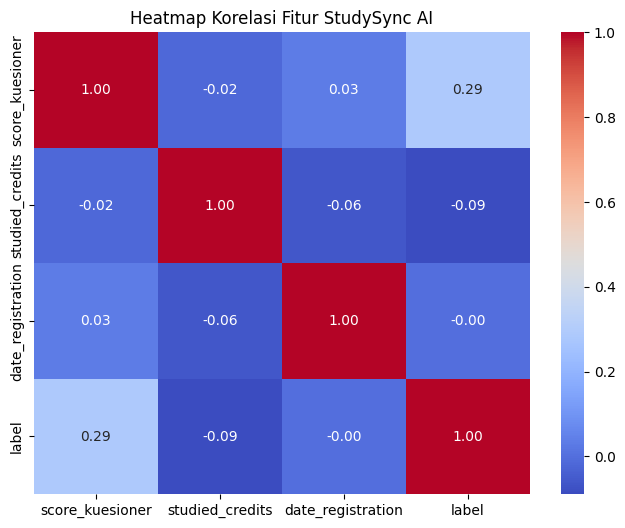

In [82]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_final_studysync[['score_kuesioner', 'studied_credits', 'date_registration', 'label']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur StudySync AI')
plt.show()

*  Fitur score_kuesioner memiliki korelasi positif tertinggi sebesar 0.29. Secara objektif, ini menunjukkan bahwa nilai kuis pertama adalah prediktor terbaik yang kita miliki. Mahasiswa yang mampu beradaptasi dan meraih nilai bagus di awal semester memiliki kecenderungan lebih tinggi untuk lulus, sehingga fitur ini wajib menjadi input utama dalam aplikasi kita.
* Fitur studied_credits menunjukkan korelasi negatif sebesar -0.09. Walaupun angkanya kecil, tanda negatif ini sangat krusial karena mengonfirmasi teori bahwa semakin besar beban SKS yang diambil, peluang kelulusan sedikit menurun. Hal ini memberi dasar bagi AI kita untuk memberikan peringatan risiko burnout kepada user yang mengambil beban mata kuliah terlalu tinggi.
* Harus diakui bahwa angka korelasi di bawah 0.30 dikategorikan sebagai korelasi yang lemah. Hal ini menunjukkan adanya "missing context" atau faktor luar (seperti motivasi pribadi, kendala ekonomi, atau interaksi sosial) yang tidak tertangkap oleh dataset ini.

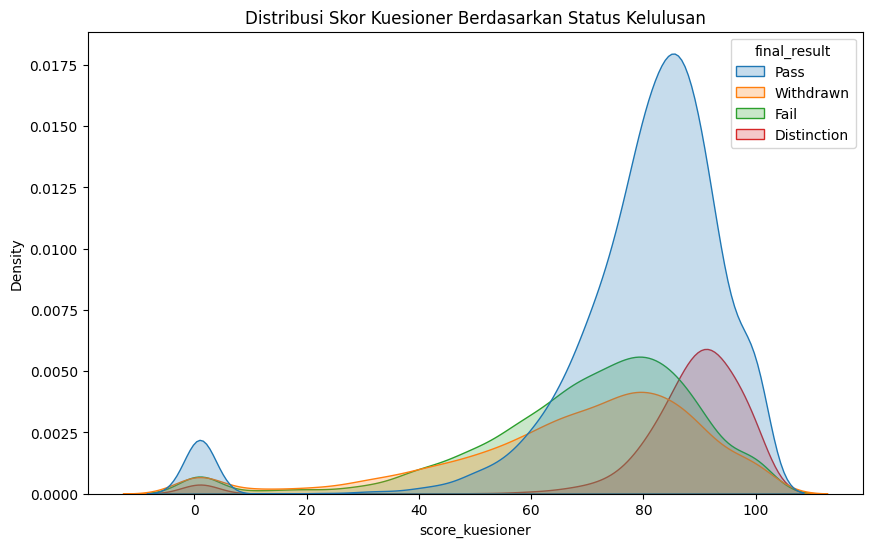

In [83]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_final_studysync, x='score_kuesioner', hue='final_result', fill=True)
plt.title('Distribusi Skor Kuesioner Berdasarkan Status Kelulusan')
plt.show()

* Secara visual, kelompok Distinction (merah) dan Pass (biru) menumpuk di sisi kanan grafik (skor 80-100). Ini menunjukkan adanya korelasi positif yang jelas: semakin tinggi skor kuesioner, semakin besar peluang mahasiswa berada di kategori kelulusan terbaik. Puncak tertinggi pada skor ~85 menunjukkan bahwa mayoritas mahasiswa yang lulus memiliki pemahaman materi awal yang sangat solid.
* Ada gundukan kecil yang mencurigakan di area skor 0-10. Ini menunjukkan adanya sekelompok mahasiswa yang langsung menyerah atau tidak mengerjakan kuis sama sekali sejak awal. Mayoritas dari mereka berakhir dengan status Withdrawn (oranye) atau Fail (hijau). Di area tesebut juga ada banyak siswa yang Pass atau lulus, ini bisa mengindikasikan bahwa kuis pertama belum tentu menentukan lulus atau tidaknya seseorang.

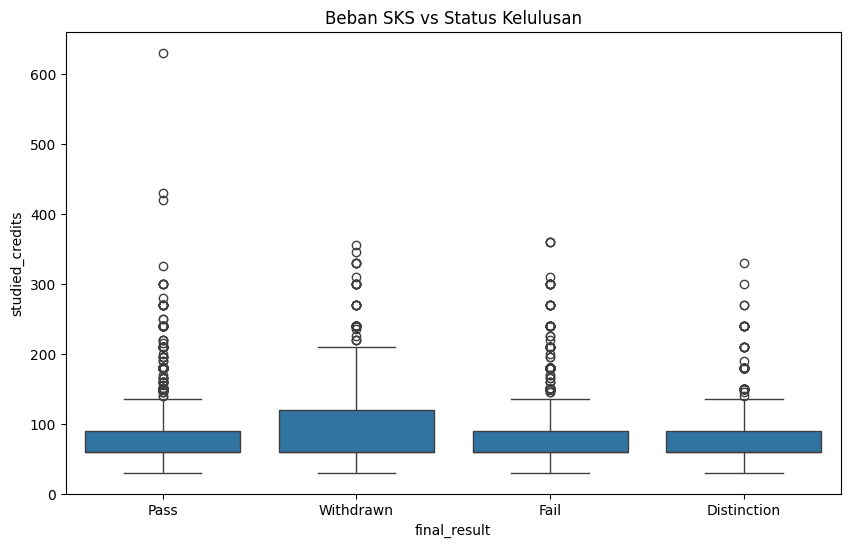

In [84]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final_studysync, x='final_result', y='studied_credits')
plt.title('Beban SKS vs Status Kelulusan')
plt.show()

* Secara umum, median SKS untuk kelompok Pass, Fail, dan Distinction berada di level yang sangat mirip (sekitar 60–90 SKS). Ini menjelaskan kenapa korelasinya kecil; artinya, selama mahasiswa berada di beban belajar normal, jumlah SKS tidak menjadi penentu utama kelulusan mereka.
* Perhatikan boxplot Withdrawn. Kotaknya (IQR) jauh lebih tinggi dan lebar dibanding yang lain. Mediannya juga tampak sedikit lebih tinggi. Ini membuktikan secara visual bahwa mahasiswa yang mengambil SKS lebih banyak (di atas 100) memiliki risiko lebih tinggi untuk mundur di tengah jalan. Mereka mungkin merasa kewalahan (overwhelmed) dengan beban materi.


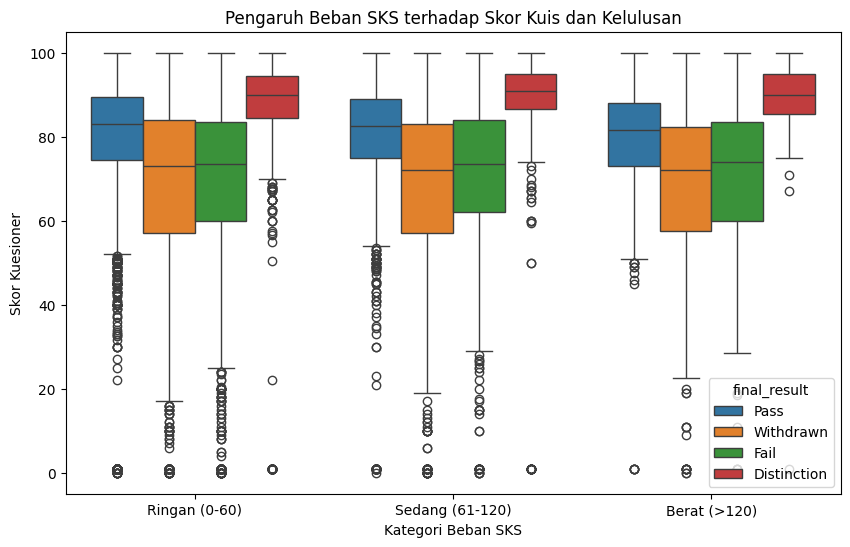

In [85]:
# Kelompokkan SKS ke dalam kategori (Beban Ringan, Sedang, Berat)
bins = [0, 60, 120, 300]
labels = ['Ringan (0-60)', 'Sedang (61-120)', 'Berat (>120)']
df_final_studysync['sks_category'] = pd.cut(df_final_studysync['studied_credits'], bins=bins, labels=labels)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final_studysync, x='sks_category', y='score_kuesioner', hue='final_result')
plt.title('Pengaruh Beban SKS terhadap Skor Kuis dan Kelulusan')
plt.ylabel('Skor Kuesioner')
plt.xlabel('Kategori Beban SKS')
plt.show()

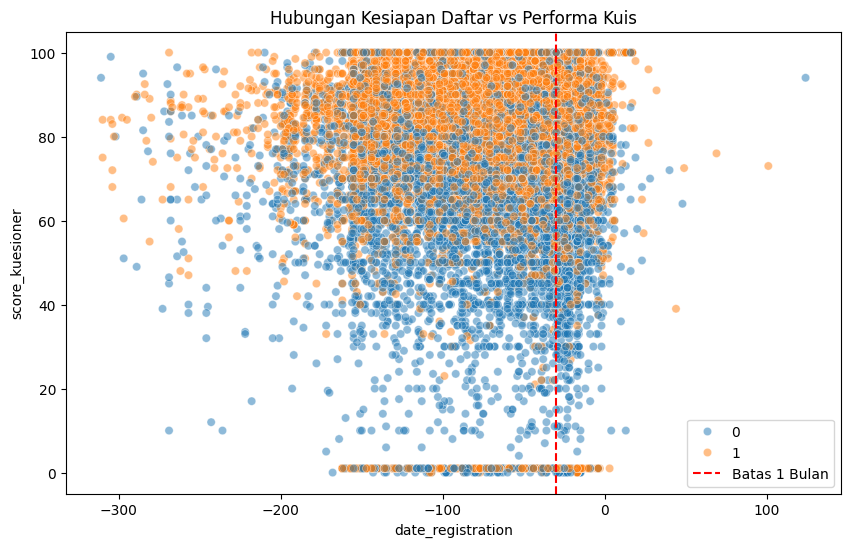

In [86]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final_studysync, x='date_registration', y='score_kuesioner', hue='label', alpha=0.5)
plt.axvline(x=-30, color='red', linestyle='--', label='Batas 1 Bulan')
plt.title('Hubungan Kesiapan Daftar vs Performa Kuis')
plt.legend()
plt.show()

/tmp/ipykernel_13262/1660466321.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  score_insight = df_final_studysync.groupby('score_range')['label'].mean() * 100


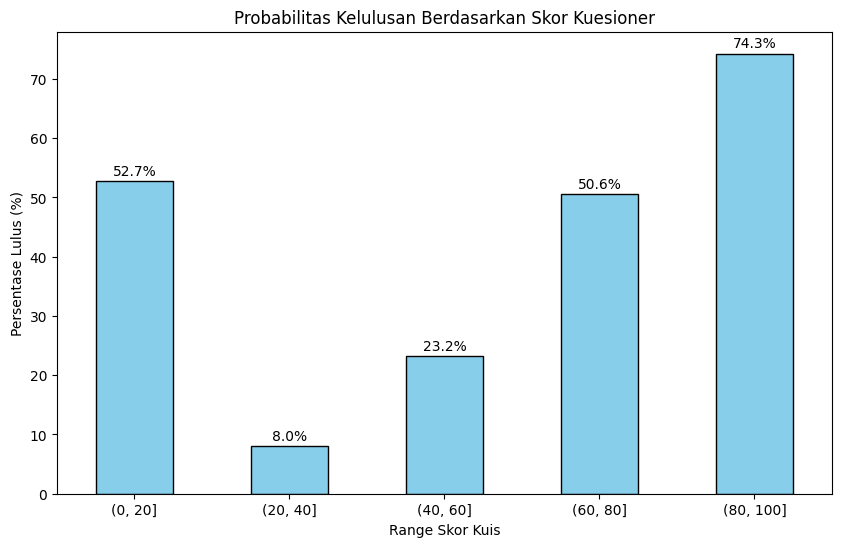

In [87]:
# Buat kategori skor (0-20, 21-40, dst)
df_final_studysync['score_range'] = pd.cut(df_final_studysync['score_kuesioner'], bins=range(0, 101, 20))

# Hitung persentase lulus per kategori
score_insight = df_final_studysync.groupby('score_range')['label'].mean() * 100

plt.figure(figsize=(10, 6))
score_insight.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Probabilitas Kelulusan Berdasarkan Skor Kuesioner')
plt.ylabel('Persentase Lulus (%)')
plt.xlabel('Range Skor Kuis')
plt.xticks(rotation=0)
for i, v in enumerate(score_insight):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.show()

# DIBAWAH INI EDA BUAT DATA YANG DILUAR DATA BUAT AI

# DIBAWAH INI EDA BUAT DATA YANG DILUAR DATA BUAT AI

# DIBAWAH INI EDA BUAT DATA YANG DILUAR DATA BUAT AI

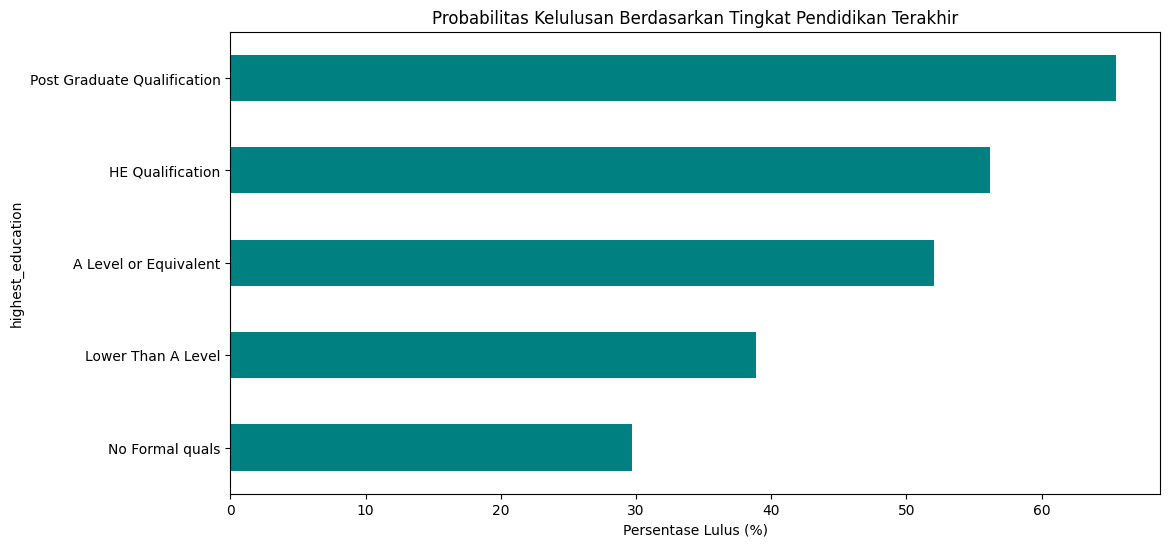

In [88]:
plt.figure(figsize=(12, 6))
# Hitung rata-rata kelulusan (label) per kategori pendidikan
edu_prob = student_info.groupby('highest_education')['final_result'].apply(lambda x: (x.isin(['Pass', 'Distinction'])).mean() * 100).sort_values()

edu_prob.plot(kind='barh', color='teal')
plt.title('Probabilitas Kelulusan Berdasarkan Tingkat Pendidikan Terakhir')
plt.xlabel('Persentase Lulus (%)')
plt.show()

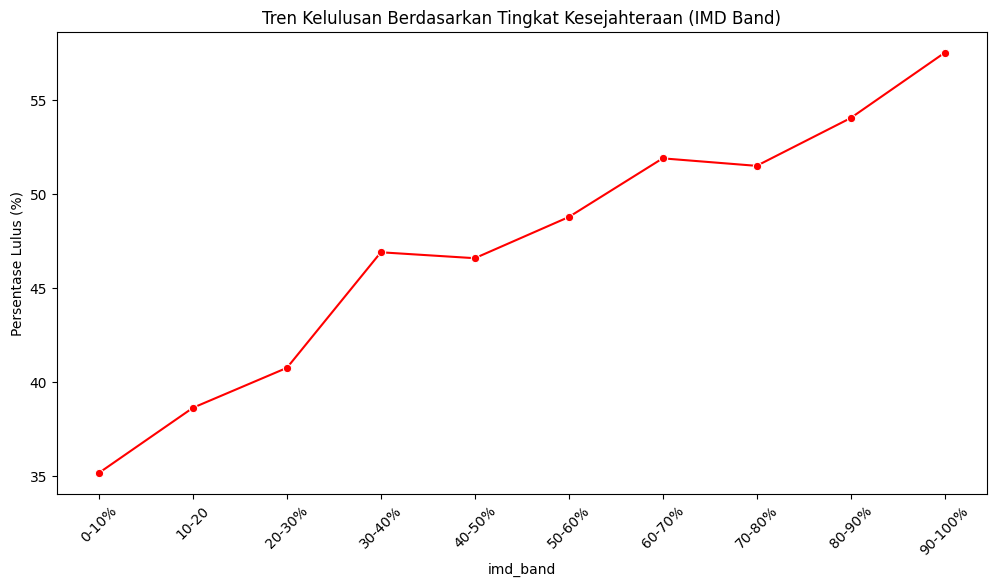

In [89]:
plt.figure(figsize=(12, 6))
imd_prob = student_info.groupby('imd_band')['final_result'].apply(lambda x: (x.isin(['Pass', 'Distinction'])).mean() * 100)

sns.lineplot(x=imd_prob.index, y=imd_prob.values, marker='o', color='red')
plt.title('Tren Kelulusan Berdasarkan Tingkat Kesejahteraan (IMD Band)')
plt.ylabel('Persentase Lulus (%)')
plt.xticks(rotation=45)
plt.show()

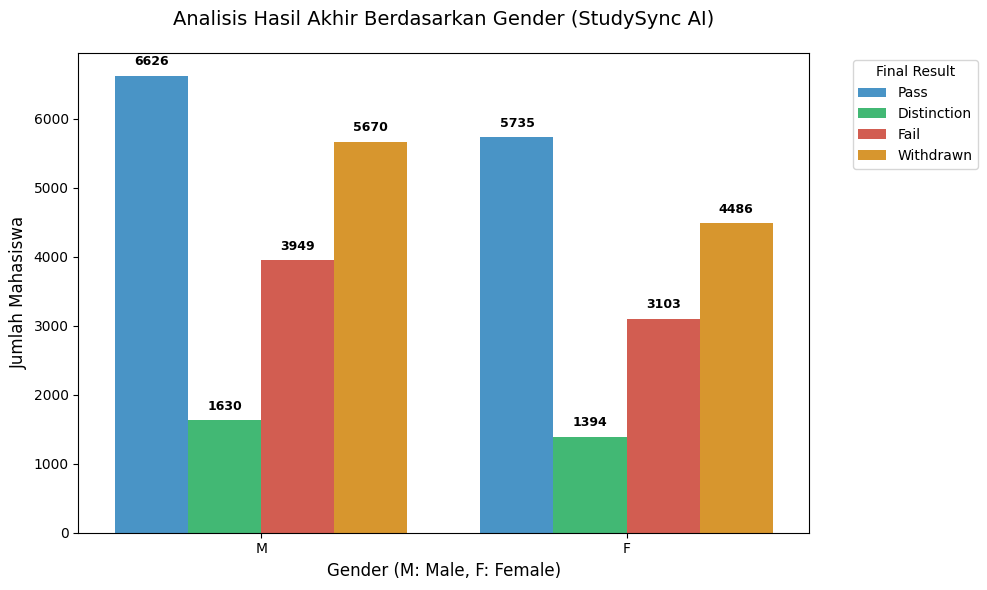

In [90]:
# 1. Setting urutan dan warna agar informatif
result_order = ['Pass', 'Distinction', 'Fail', 'Withdrawn']
# Biru (Lulus), Hijau (Istimewa), Merah (Gagal), Oranye (Mundur)
palette = {'Pass': '#3498db', 'Distinction': '#2ecc71', 'Fail': '#e74c3c', 'Withdrawn': '#f39c12'}

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=student_info, x='gender', hue='final_result', hue_order=result_order, palette=palette)

# 2. Tambahkan Judul dan Label
plt.title('Analisis Hasil Akhir Berdasarkan Gender (StudySync AI)', fontsize=14, pad=20)
plt.ylabel('Jumlah Mahasiswa', fontsize=12)
plt.xlabel('Gender (M: Male, F: Female)', fontsize=12)
plt.legend(title='Final Result', bbox_to_anchor=(1.05, 1), loc='upper left')

# 3. Tambahkan angka di atas setiap bar (Data Annotation)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 10),
                    textcoords='offset points',
                    fontsize=9,
                    fontweight='bold')

plt.tight_layout()
plt.show()

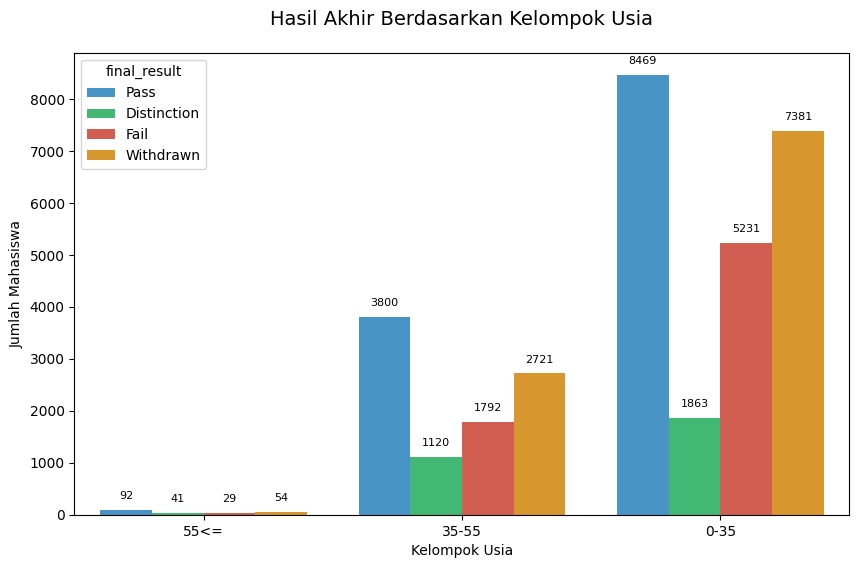

In [91]:
# Pastikan setting warna tetap konsisten
result_order = ['Pass', 'Distinction', 'Fail', 'Withdrawn']
palette = {'Pass': '#3498db', 'Distinction': '#2ecc71', 'Fail': '#e74c3c', 'Withdrawn': '#f39c12'}

# --- 1. Analisis Berdasarkan Kelompok Usia (Age Band) ---
plt.figure(figsize=(10, 6))
ax1 = sns.countplot(data=student_info, x='age_band', hue='final_result', hue_order=result_order, palette=palette)
plt.title('Hasil Akhir Berdasarkan Kelompok Usia', fontsize=14, pad=20)
plt.ylabel('Jumlah Mahasiswa')
plt.xlabel('Kelompok Usia')

for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=8)
plt.show()

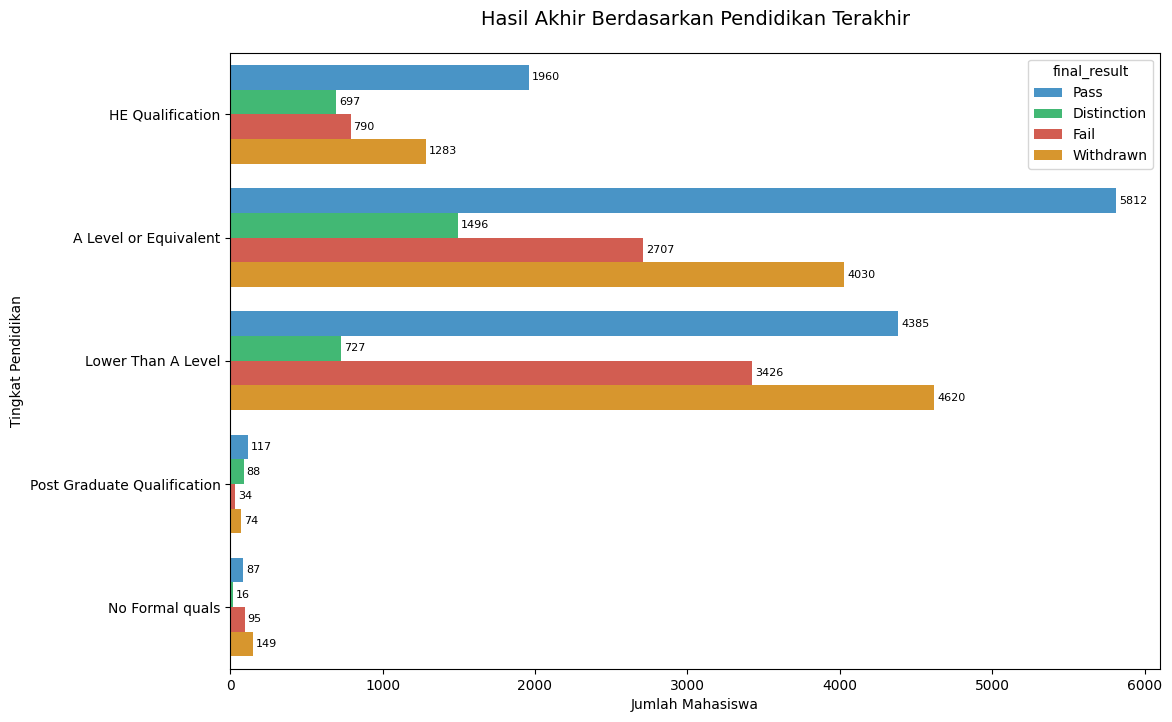

In [92]:
# --- 2. Analisis Berdasarkan Pendidikan Terakhir (Highest Education) ---
plt.figure(figsize=(12, 8))
# Kita pake horizontal bar (y='highest_education') karena nama pendidikannya panjang-panjang
ax2 = sns.countplot(data=student_info, y='highest_education', hue='final_result', hue_order=result_order, palette=palette)
plt.title('Hasil Akhir Berdasarkan Pendidikan Terakhir', fontsize=14, pad=20)
plt.xlabel('Jumlah Mahasiswa')
plt.ylabel('Tingkat Pendidikan')

# Anotasi untuk bar horizontal agak beda posisinya
for p in ax2.patches:
    if p.get_width() > 0:
        ax2.annotate(f'{int(p.get_width())}', (p.get_width() + 20, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', fontsize=8)
plt.show()